In [1]:
%matplotlib inline
import pandas as pd

In [2]:
from IPython.core.display import HTML
css = open('style-table.css').read() + open('style-notebook.css').read()
HTML('<style>{}</style>'.format(css))

In [3]:
sales1 = pd.read_csv('sales1.csv')
sales1

,Book title,Number sold,Sales price,Royalty paid
0,The Bricklayer’s Bible,8,2.99,0.55
1,Swimrand,2,1.99,0.35
2,Pining For The Fisheries of Yore,28,2.99,0.55
3,The Duck Goes Here,34,2.99,0.55
4,The Tower Commission Report,4,11.50,4.25


In [4]:
sales2 = pd.read_csv('sales2.csv')
sales2.fillna('')

,Title,Units sold,List price,Royalty
0,,,,
1,Sales report for Q4,,,
2,E-Book Reader US Store,,,
3,Pining for the Fisheries of Yore,80.0,3.5,14.98
4,Swimrand,1.0,2.99,0.14
5,The Bricklayer's Bible,17.0,3.5,5.15
6,The Duck Goes Here,34.0,2.99,5.78
7,The Tower Commission Report,4.0,9.5,6.2
8,US royalties (USD),,,32.25
9,,,,


### Challenge: first combine these sales together into a single dataframe, then compute how much money consumers spent on each book in each currency.

In [24]:
#assume sales1 is in USD; sales price is what the book is sold for; royalty is what we got

#1. clean up sales1

s1 = sales1.copy()

#a. rename column headers
#b. add currency column
s1 = s1.rename(columns={'Book title': 'Title', 'Number sold': 'Units sold', 'Sales price': 'Price', 'Royalty paid': 'Royalty'})
s1['Currency'] = 'USD'
s1



,Title,Units sold,Price,Royalty,Currency
0,The Bricklayer’s Bible,8,2.99,0.55,USD
1,Swimrand,2,1.99,0.35,USD
2,Pining For The Fisheries of Yore,28,2.99,0.55,USD
3,The Duck Goes Here,34,2.99,0.55,USD
4,The Tower Commission Report,4,11.50,4.25,USD


In [111]:
#2. clean up sales 2

s2 = sales2.copy()

#a. rename column headers
s2 = s2.rename(columns={'List price': 'Price'})

#b. Remove empty rows
s2 = s2.dropna(how='all')
s2 = s2.drop(s2[s2.Title == 'Sales report for Q4'].index)

#c. Take 'E-Book Reader XX Store' as start of the report
header = s2.Title.str.contains('E-Book Reader') & s2.Title.str.contains('Store')
start = s2[header].index

#d. Take 'XX royalties (XXX)' as end of the report
footer = s2.Title.str.contains('royalties') & s2.Price.isna()
end = s2[footer].index

#e. add currency column
s2['Currency'] = ''

def get_currency(end_idx):
    # get currency from footer
    f = s2.loc[end_idx, 'Title']
    str1 = f.find('(')
    str2 = f.find(')')
    curr = f[str1+1:str2]
    return curr

for i in range(len(start)):
    #find start and end index pairs
    start_idx = start[i]
    end_idx = end[i]

    #get currency and fill column
    curr = get_currency(end_idx)
    s2.loc[start_idx:end_idx, 'Currency'] = curr

#f. drop header and footer rows
s2 = s2.dropna()

s2

,Title,Units sold,Price,Royalty,Currency
3,Pining for the Fisheries of Yore,80.0,3.50,14.98,USD
4,Swimrand,1.0,2.99,0.14,USD
5,The Bricklayer's Bible,17.0,3.50,5.15,USD
6,The Duck Goes Here,34.0,2.99,5.78,USD
7,The Tower Commission Report,4.0,9.50,6.20,USD
13,Pining for the Fisheries of Yore,47.0,2.99,11.98,GBP
14,The Bricklayer's Bible,17.0,2.99,3.50,GBP
15,The Tower Commission Report,4.0,6.50,4.80,GBP
21,Swimrand,8.0,1.99,0.88,EUR
22,The Duck Goes Here,12.0,1.99,1.50,EUR


In [155]:
#3. merge s1 & s2.

sales = pd.concat([s1,s2])
sales


,Title,Units sold,Price,Royalty,Currency
0,The Bricklayer’s Bible,8.0,2.99,0.55,USD
1,Swimrand,2.0,1.99,0.35,USD
2,Pining For The Fisheries of Yore,28.0,2.99,0.55,USD
3,The Duck Goes Here,34.0,2.99,0.55,USD
4,The Tower Commission Report,4.0,11.50,4.25,USD
3,Pining for the Fisheries of Yore,80.0,3.50,14.98,USD
4,Swimrand,1.0,2.99,0.14,USD
5,The Bricklayer's Bible,17.0,3.50,5.15,USD
6,The Duck Goes Here,34.0,2.99,5.78,USD
7,The Tower Commission Report,4.0,9.50,6.20,USD


Axes(0.125,0.11;0.775x0.77)
Axes(0.125,0.11;0.775x0.77)


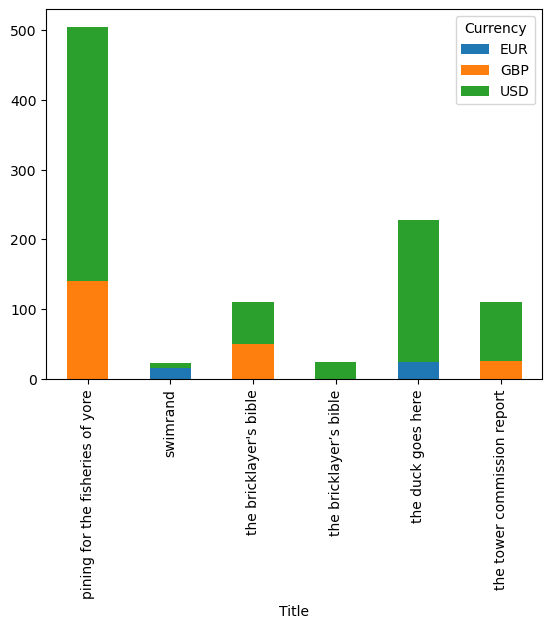

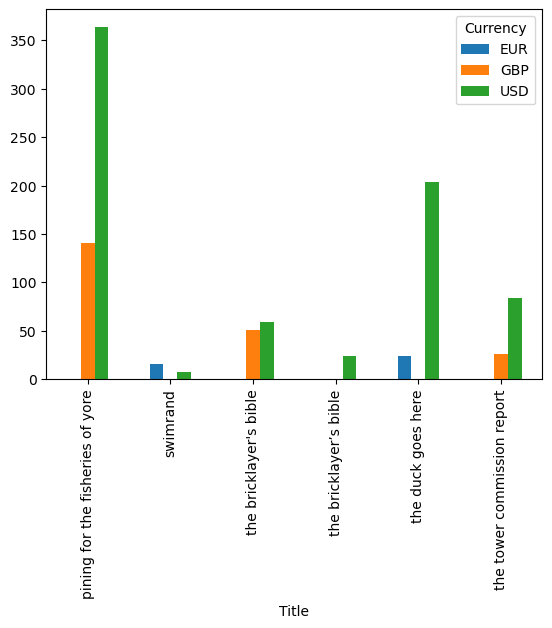

In [165]:
#4. compute how much money consumers spent on each book in each currency
s = sales

s.Title = s.Title.str.lower() #clean up title
s['Total'] = s.Price * s['Units sold'] #find total spent

s = s.groupby(['Title','Currency']).Total.sum()
s = s.unstack().fillna(0)

stacked_bar = s.plot(kind='bar', stacked=True)
print(stacked_bar)

grouped_bar = s.plot(kind='bar')
print(grouped_bar)
